# Code 8.13：完整顺序运行入口

依次执行 00--06。


In [83]:
%run './00_config.ipynb'


配置参数数量: 69


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


,参数,含义,默认值,状态
0,PROJECT_PATH,项目目录,PosixPath('/Users/mac/Desktop/实习/skew_strategy...,已设置
1,UNDERLYING_DATA_PATH,标的原始数据路径,PosixPath('数据/标的_2026-06~07.csv'),已设置
2,FUTURE_DATA_PATH,IM期货原始数据路径；当前与标的数据共用文件,PosixPath('数据/标的_2026-06~07.csv'),已设置
3,OPTION_DATA_PATH,MO期权原始数据路径,PosixPath('数据/MO_2026-06~07.csv'),已设置
4,OUTPUT_PATH,通用输出目录,PosixPath('/Users/mac/Desktop/实习/skew_strategy...,已设置
...,...,...,...,...
64,STRATEGY_OPTION_MARGIN_RATE,卖出期权保证金中的标的保证金率,0.12,已设置
65,STRATEGY_MINIMUM_MARGIN_RATE,卖出期权最低保证金率,0.06,已设置
66,STRATEGY_INTEGER_OPTION_POSITIONS,是否将06策略期权仓位取整,True,已设置
67,STRATEGY_INTEGER_FUTURES_POSITIONS,是否将06策略期货对冲仓位取整,True,已设置


In [84]:
%run './02_basic_functions.ipynb'


02_basic_functions.ipynb 当前参数：
TRADING_DAYS_PER_YEAR = 365
EXPIRY_DATE_OVERRIDES = {'2606': '2026-06-22'}


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


,测试,解析结果,差分/目标结果,绝对误差,容差,通过
0,Put-call parity,0.000000,0.000000,0.000000e+00,1.000000e-09,True
1,Forward Delta,0.440416,0.440416,1.845401e-10,1.000000e-07,True
2,Forward Gamma,0.000784,0.000784,8.649376e-11,1.000000e-07,True
3,Vega,899.721761,899.721761,1.719548e-08,1.000000e-05,True
4,Volga,136.103995,136.099629,4.365461e-03,2.000000e-02,True
5,Vanna,0.403348,0.403348,5.226220e-09,1.000000e-05,True
6,Spot Delta conversion,0.440796,0.440796,1.848813e-10,1.000000e-07,True
7,Spot Gamma conversion,0.000785,0.000785,6.153099e-11,1.000000e-07,True
8,Repo Rho,-353.240702,-353.240702,1.720589e-07,1.000000e-04,True
9,Rho,333.773522,333.773522,1.852230e-07,1.000000e-04,True


,测试,结果,通过
0,期权代码解析,"{'expiry_code': '2606', 'expiry_year': 2026, '...",True
1,期货代码解析,"{'expiry_code': '202407', 'expiry_year': 2024,...",True
2,2606特殊到期日,2026-06-22,True
3,2607第三个周五,2026-07-17,True
4,Delta执行价搜索,"{'strike': 6900.0, 'log_moneyness': 0.05885622...",True
5,曲面中心差分接口,"{'ATM': 2.000000000066393, 'Skew': 2.999999999...",True


In [85]:
%run './01_data_processing.ipynb'


01_data_processing.ipynb 当前参数：
UNDERLYING_DATA_PATH = PosixPath('数据/标的_2026-06~07.csv')
FUTURE_DATA_PATH = PosixPath('数据/标的_2026-06~07.csv')
OPTION_DATA_PATH = PosixPath('数据/MO_2026-06~07.csv')
UNDERLYING_CODE = '000852.SH'
UNDERLYING_PRICE_FIELD = 'CLOSE'
FUTURE_PREFIX = 'IM'
FUTURE_PRICE_FIELD = 'CLOSE'
OPTION_PREFIX = 'MO'
OPTION_RAW_PRICE_FIELD = 'S_DQ_CLOSE'
START_DATE = '2026-06-01'
END_DATE = '2026-07-29'
TRADING_DAYS_PER_YEAR = 365
PROCESSED_DATA_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/01_processed_data')
EXPIRY_DATE_OVERRIDES = {'2606': '2026-06-22'}
FILTER_ZERO_VOLUME = False
SAVE_CSV = True
Underlying data loading completed
Rows: 42
Date range: 2026-06-01 - 2026-07-29


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


,TRADE_DT,CODE,CLOSE
0,2026-06-01,000852.SH,8345.1291
1,2026-06-02,000852.SH,8384.7812
2,2026-06-03,000852.SH,8432.6790
3,2026-06-04,000852.SH,8420.0946
4,2026-06-05,000852.SH,8340.9631


Future data loading completed
Rows: 168
Date range: 2026-06-01 - 2026-07-29


,TRADE_DT,CODE,CLOSE,VOLUME,OI,EXPIRY_CODE,EXPIRY
0,2026-06-01,IM2606.CFE,8305.8,185978.0,219745.0,2606,2026-06-22
1,2026-06-01,IM2607.CFE,8235.2,10555.0,16869.0,2607,2026-07-17
2,2026-06-01,IM2609.CFE,8081.8,58978.0,141306.0,2609,2026-09-18
3,2026-06-01,IM2612.CFE,7880.4,22039.0,66830.0,2612,2026-12-18
4,2026-06-02,IM2606.CFE,8324.6,175916.0,210218.0,2606,2026-06-22


...

Expiry count: 8


EXPIRY
2026-06-22    82
2026-07-17    64
2026-08-21    74
2026-09-18    76
2026-10-16    38
2026-12-18    40
2027-03-19    40
2027-06-18    38
Name: CONTRACT_COUNT, dtype: int64

Daily option count summary


count     42.000000
mean     289.571429
std       15.241380
min      266.000000
25%      271.000000
50%      294.000000
75%      304.000000
max      306.000000
Name: CODE, dtype: float64


Standardized panel columns
underlying_panel: ['TRADE_DT', 'CODE', 'CLOSE']
future_panel: ['TRADE_DT', 'CODE', 'CLOSE', 'VOLUME', 'OI', 'EXPIRY_CODE', 'EXPIRY']
option_panel: ['TRADE_DT', 'CODE', 'EXPIRY', 'TYPE', 'STRIKE', 'PRICE', 'VOLUME', 'OI', 'TAU', 'EXPIRY_CODE']
Processed data saved:
  underlying_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/01_processed_data/underlying_panel.csv
  future_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/01_processed_data/future_panel.csv
  option_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/01_processed_data/option_panel.csv
  trading_dates: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/01_processed_data/trading_dates.csv


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


03_repo_forward.ipynb 当前参数：
RISK_FREE_RATE = 0.015
REPO_RECALC_FREQ = 10
MAIN_FUTURE_SELECTION = 'VOLUME'
REPO_FORWARD_OUTPUT_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/03_repo_forward')
SAVE_CSV = True
Main future selection completed


,TRADE_DT,CODE,PRICE,VOLUME,OI,EXPIRY_CODE,EXPIRY,TAU
0,2026-06-01,IM2606.CFE,8305.8,185978.0,219745.0,2606,2026-06-22,0.057534
1,2026-06-02,IM2606.CFE,8324.6,175916.0,210218.0,2606,2026-06-22,0.054795
2,2026-06-03,IM2606.CFE,8368.4,172909.0,201325.0,2606,2026-06-22,0.052055
3,2026-06-04,IM2606.CFE,8354.8,131965.0,191874.0,2606,2026-06-22,0.049315
4,2026-06-05,IM2606.CFE,8291.8,181451.0,200773.0,2606,2026-06-22,0.046575


Repo construction completed


,TRADE_DT,raw_repo_rate,REPO,UPDATED,SCHEDULED_UPDATE,STATUS,RISK_FREE_RATE,REPO_SOURCE_DATE,MAIN_FUTURE_CODE,MAIN_FUTURE_PRICE,MAIN_FUTURE_EXPIRY,MAIN_FUTURE_TAU,SPOT_AT_UPDATE
0,2026-06-01,0.097107,0.097107,True,True,UPDATED,0.015,2026-06-01,IM2606.CFE,8305.8,2026-06-22,0.057534,8345.1291
1,2026-06-02,0.146460,0.097107,False,False,CARRY_FORWARD,0.015,2026-06-01,IM2606.CFE,8305.8,2026-06-22,0.057534,8345.1291
2,2026-06-03,0.161995,0.097107,False,False,CARRY_FORWARD,0.015,2026-06-01,IM2606.CFE,8305.8,2026-06-22,0.057534,8345.1291
3,2026-06-04,0.172859,0.097107,False,False,CARRY_FORWARD,0.015,2026-06-01,IM2606.CFE,8305.8,2026-06-22,0.057534,8345.1291
4,2026-06-05,0.141926,0.097107,False,False,CARRY_FORWARD,0.015,2026-06-01,IM2606.CFE,8305.8,2026-06-22,0.057534,8345.1291


...

Forward panel preview


,TRADE_DT,EXPIRY_CODE,EXPIRY,TAU,SPOT,REPO,RISK_FREE_RATE,FORWARD,SOURCE,MARKET_FUTURE_CODE,MARKET_FUTURE_PRICE
0,2026-06-01,2606,2026-06-22,0.057534,8345.1291,0.097107,0.015,8305.800000,FUTURE,IM2606.CFE,8305.8
1,2026-06-01,2607,2026-07-17,0.126027,8345.1291,0.097107,0.015,8235.200000,FUTURE,IM2607.CFE,8235.2
2,2026-06-01,2608,2026-08-21,0.221918,8345.1291,0.097107,0.015,8194.449488,REPO,NaN,NaN
3,2026-06-01,2609,2026-09-18,0.298630,8345.1291,0.097107,0.015,8081.800000,FUTURE,IM2609.CFE,8081.8
4,2026-06-01,2612,2026-12-18,0.547945,8345.1291,0.097107,0.015,7880.400000,FUTURE,IM2612.CFE,7880.4


Option forward panel preview


,TRADE_DT,CODE,EXPIRY,TYPE,STRIKE,PRICE,VOLUME,OI,TAU,EXPIRY_CODE,FORWARD,SOURCE,SPOT,REPO,RISK_FREE_RATE
0,2026-06-01,MO2606-C-5200.CFE,2026-06-22,CALL,5200.0,3108.2,30.0,221.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015
1,2026-06-01,MO2606-C-5400.CFE,2026-06-22,CALL,5400.0,2920.8,24.0,126.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015
2,2026-06-01,MO2606-C-5600.CFE,2026-06-22,CALL,5600.0,2727.8,46.0,223.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015
3,2026-06-01,MO2606-C-5800.CFE,2026-06-22,CALL,5800.0,2528.6,58.0,165.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015
4,2026-06-01,MO2606-C-6000.CFE,2026-06-22,CALL,6000.0,2302.0,58.0,261.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015


,CHECK,PASSED,DETAIL
0,主力日期唯一,True,每个日期最多一个主力
1,主力覆盖全部交易日,True,42/42
2,主力TAU为正,True,min=0.013699
3,Repo日期完整,True,42/42
4,Raw Repo为有限值,True,每日即时估计无NaN/Inf
5,Repo为有限值,True,持有序列无NaN/Inf
6,Repo更新计划正确,True,"[datetime.date(2026, 6, 1), datetime.date(2026..."
7,Forward键唯一,True,TRADE_DT+EXPIRY
8,Forward全部为正,True,invalid=0
9,Repo Forward公式一致,True,max_error=0.000e+00


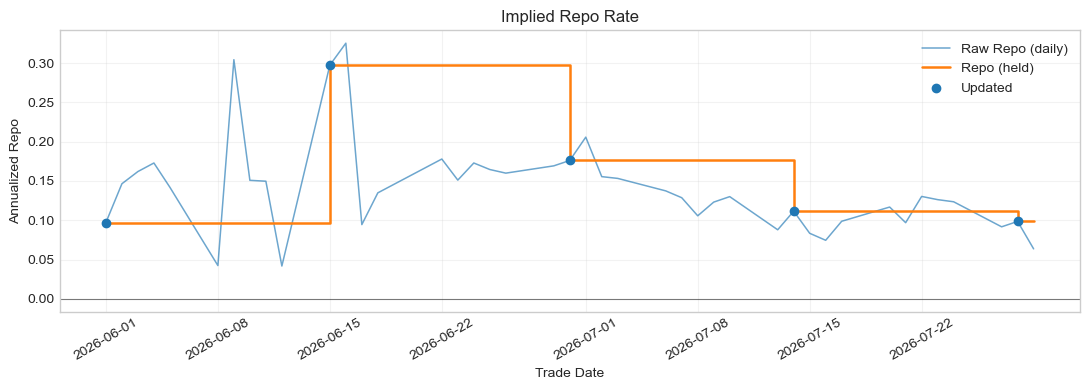

Repo/Forward results saved:
  main_future_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/03_repo_forward/main_future_panel.csv
  repo_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/03_repo_forward/repo_panel.csv
  forward_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/03_repo_forward/forward_panel.csv
  option_forward_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/03_repo_forward/option_forward_panel.csv


In [86]:
%run './03_repo_forward.ipynb'


In [87]:
%run './04_volatility_model.ipynb'


04_volatility_model.ipynb 当前参数：
VOL_MODEL = 'QUADRATIC'
MIN_OTM_OPTIONS_PER_EXPIRY = 6
MIN_OPTION_PRICE = 1e-08
MIN_IV = None
MAX_IV = 5.0
SVI_PARAMETER_BOUNDS = {'a': (None, None), 'b': (None, None), 'rho': (None, None), 'm': (None, None), 'sigma': (None, None)}
VOL_SURFACE_DELTA_BASIS = 'FORWARD'
VOL_SURFACE_TARGET_DELTAS = {'90PUT': -0.1, '25CALL': 0.25, '75PUT': -0.25, '10CALL': 0.1}
ATM_LOG_MONEYNESS = 0.0
IV_SOLVER_LOWER_BOUND = 1e-06
IV_SOLVER_TOLERANCE = 1e-08
IV_SOLVER_MAX_ITERATIONS = 200
MODEL_SKEW_TAG = 'QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE'
VOLATILITY_MODEL_OUTPUT_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE')
IV_CURVE_FIGURE_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/figures/IV_curve')
SAVE_CSV = True
SAVE_FIGURE = True
FIGURE_FORMAT = 'png'


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


IV calculation completed
IV_STATUS
OK                               11042
价格不高于Black-76内在价值边界                974
PRICE、FORWARD、STRIKE和TAU必须大于零      146
Name: count, dtype: int64


,TRADE_DT,CODE,EXPIRY,TYPE,STRIKE,PRICE,VOLUME,OI,TAU,EXPIRY_CODE,FORWARD,SOURCE,SPOT,REPO,RISK_FREE_RATE,LOG_MONEYNESS,IS_OTM,IV,IV_STATUS
0,2026-06-01,MO2606-C-5200.CFE,2026-06-22,CALL,5200.0,3108.2,30.0,221.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015,-0.468295,False,0.853390,OK
1,2026-06-01,MO2606-P-5200.CFE,2026-06-22,PUT,5200.0,0.8,26.0,2330.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015,-0.468295,True,0.694542,OK
2,2026-06-01,MO2606-C-5400.CFE,2026-06-22,CALL,5400.0,2920.8,24.0,126.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015,-0.430555,False,0.952536,OK
3,2026-06-01,MO2606-P-5400.CFE,2026-06-22,PUT,5400.0,1.0,21.0,803.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015,-0.430555,True,0.656784,OK
4,2026-06-01,MO2606-C-5600.CFE,2026-06-22,CALL,5600.0,2727.8,46.0,223.0,0.057534,2606,8305.8,FUTURE,8345.1291,0.097107,0.015,-0.394187,False,0.936413,OK


Volatility model calibration completed


...

TARGET,TRADE_DT,EXPIRY,EXPIRY_CODE,MODEL,10CALL,25CALL,75PUT,90PUT,ATM,SKEW_25D,BF_25D,SKEW_10D
0,2026-06-01,2026-06-22,2606,QUADRATIC,0.265268,0.255822,0.258038,0.269915,0.253335,-0.002216,0.003595,-0.004647
1,2026-06-01,2026-07-17,2607,QUADRATIC,0.288752,0.281429,0.283514,0.292977,0.279605,-0.002085,0.002866,-0.004225
2,2026-06-01,2026-08-21,2608,QUADRATIC,0.296740,0.274490,0.286919,0.327474,0.272305,-0.012429,0.008399,-0.030734
3,2026-06-01,2026-09-18,2609,QUADRATIC,0.303628,0.282410,0.278018,0.292650,0.274317,0.004392,0.005897,0.010978
4,2026-06-01,2026-12-18,2612,QUADRATIC,0.293614,0.279010,0.277447,0.289550,0.273794,0.001563,0.004435,0.004064


Skew panel completed: DERIVATIVE


,TRADE_DT,EXPIRY,EXPIRY_CODE,MODEL,SKEW,SKEW_METHOD
0,2026-06-01,2026-06-22,2606,QUADRATIC,-0.033969,DERIVATIVE
1,2026-06-01,2026-07-17,2607,QUADRATIC,-0.021665,DERIVATIVE
2,2026-06-01,2026-08-21,2608,QUADRATIC,-0.085727,DERIVATIVE
3,2026-06-01,2026-09-18,2609,QUADRATIC,0.007820,DERIVATIVE
4,2026-06-01,2026-12-18,2612,QUADRATIC,-0.004393,DERIVATIVE


,CHECK,PASSED,DETAIL
0,存在有效IV,True,ok=11042/12162
1,存在OTM拟合样本,True,OTM close-price IV
2,存在成功模型,True,success=250/250
3,成功模型样本充分,True,min=6
4,成功模型RMSE有限,True,无NaN/Inf
5,ATM全部成功,True,k=0
6,Forward Delta定位可用,True,available=1000/1000
7,精确Forward Delta误差,True,max=1.900e-10; fallback=2
8,Smile指标完整,True,rows=250


IV curve figures saved: 42
Volatility model results saved:
  option_iv_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/option_iv_panel.csv
  model_parameters: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/volatility_model_parameters.csv
  delta_landmarks: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/delta_landmarks.csv
  smile_metrics: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/smile_metrics.csv
  skew_panel: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/skew_panel.csv


05_skew_curvature.ipynb 当前参数：
SKEW_METHOD = 'DERIVATIVE'
SKEW_CURVATURE_OUTPUT_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/05_skew_curvature_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE')
MODEL_SKEW_TAG = 'QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE'
SAVE_CSV = True
SAVE_FIGURE = True
FIGURE_FORMAT = 'png'


/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


,TRADE_DT,EXPIRY,SKEW
0,2026-06-01,2026-06-22,-0.033969
1,2026-06-01,2026-07-17,-0.021665
2,2026-06-01,2026-08-21,-0.085727
3,2026-06-01,2026-09-18,0.007820
4,2026-06-01,2026-12-18,-0.004393


Rows: 250, Expiries: 8
Output: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/05_skew_curvature_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE
All-expiry figure: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/05_skew_curvature_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/figures/skew_all_expiry.png
By-expiry figures: 8
Data file: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/05_skew_curvature_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/data/skew_term_structure.csv


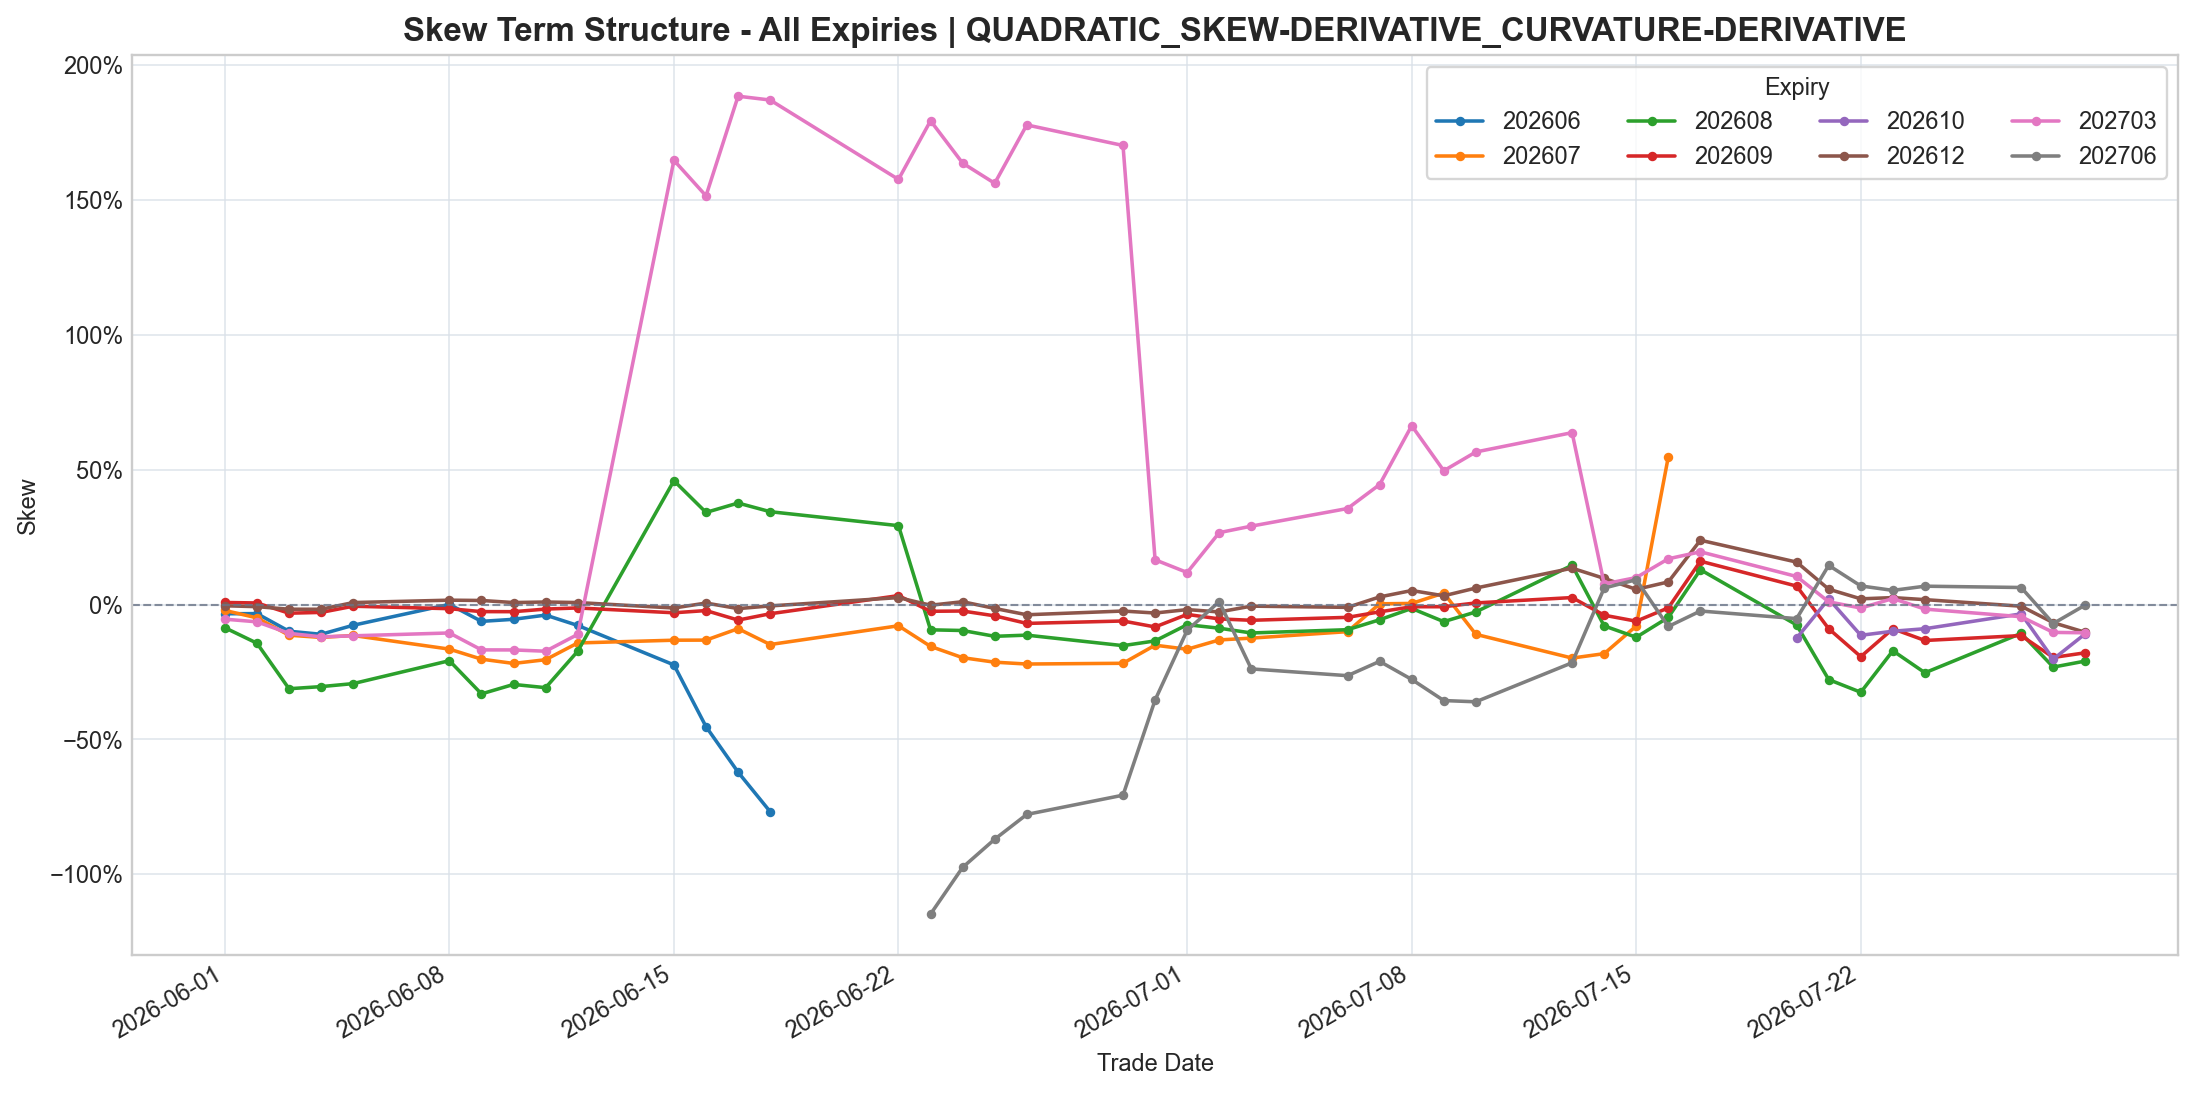

Example expiry: 202606


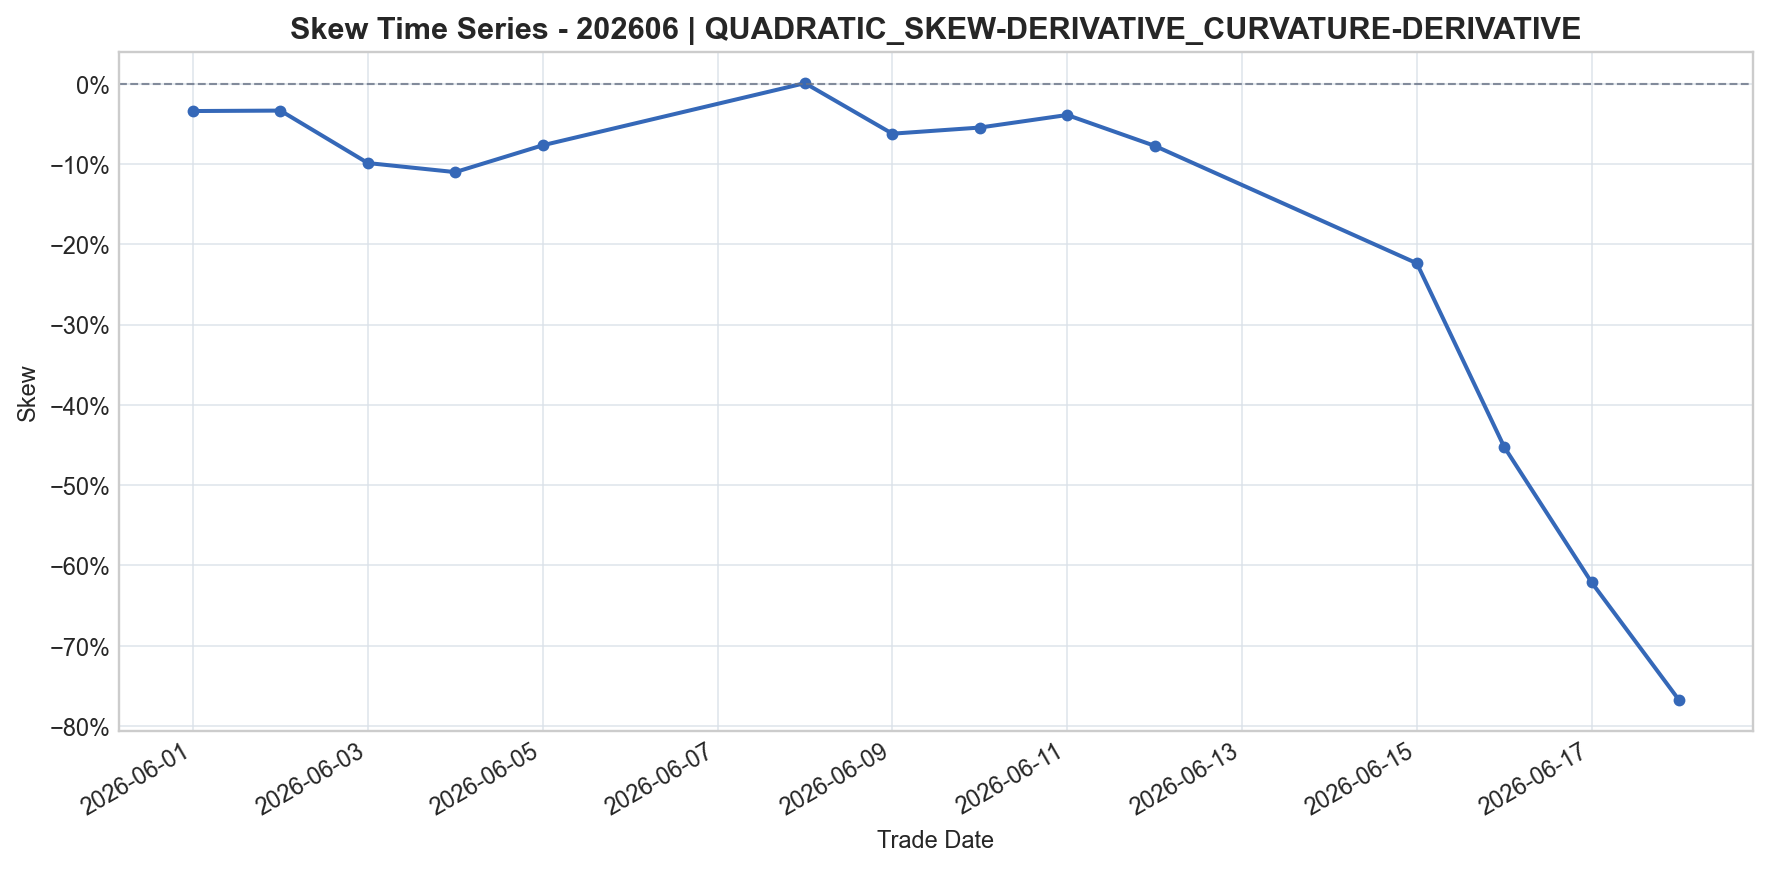

In [88]:
%run './05_skew_curvature.ipynb'


In [89]:
%run './06_skew_strategy.ipynb'


06_skew_strategy.ipynb 当前参数：
SKEW_STRATEGY_OUTPUT_PATH = PosixPath('/Users/mac/Desktop/实习/skew_strategy8.14/outputs/06_skew_strategy_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE')
VOL_MODEL = 'QUADRATIC'
MODEL_SKEW_TAG = 'QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE'
STRATEGY_MAX_OPTIONS = 9
STRATEGY_TARGET_SKEW_ABS = 10000.0
STRATEGY_MONTHLY_SKEW_DIRECTION = True
STRATEGY_HEDGE_THETA = False
STRATEGY_POSITION_BOUND = 30
STRATEGY_MAX_DAILY_TRADE_PER_LEG = 30
STRATEGY_MIN_OPTION_VOLUME = 100
STRATEGY_USE_PREMIUM_MARGIN_FILTER = True
STRATEGY_MIN_PREMIUM_MARGIN_RATIO = 0.1
STRATEGY_MAX_ABS_LOG_MONEYNESS = 0.25
STRATEGY_MAX_MODEL_IV = 1.5
STRATEGY_MIN_CANDIDATE_OPTIONS = 5
STRATEGY_MAX_CANDIDATE_EXPIRIES = 3
STRATEGY_MIN_DTE_DAYS = 10
STRATEGY_RIDGE = 0.3
STRATEGY_GROSS_POSITION_PENALTY = 0.002
STRATEGY_INTEGER_OPTION_POSITIONS = True
STRATEGY_INTEGER_FUTURES_POSITIONS = True
STRATEGY_OPTION_MULTIPLIER = 100.0
STRATEGY_OPTION_FEE_PER_CONTRACT = 15.0
STRATEGY_FUTURES_MULTIPLIER = 200.0

/opt/anaconda3/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Days: 41
Skew absolute PnL share: 55.39%
Cumulative Skew PnL: 903,628.69
Cumulative Actual PnL: 1,056,474.39
Taylor/Shapley attribution summary:
method  signed_model_residual  absolute_model_residual  skew_abs_share      skew_pnl
    T1           3.895318e+05             8.011783e+05        0.618257 917861.700980
    T2           3.733352e+04             1.808164e+05        0.563697 905238.906226
    SH           2.051365e-09             2.932256e-08        0.553938 903628.688786
Traditional Greeks Taylor attribution summary:
            method  signed_model_residual  absolute_model_residual  skew_abs_share      skew_pnl
TRADITIONAL_TAYLOR           33510.200003            260293.775842        0.525185 917861.701133
Skew holding-period segments: 41
Maximum option-leg interface: 9
Volatility model interface: QUADRATIC
Volatility parameter CSV: /Users/mac/Desktop/实习/skew_strategy8.14/outputs/04_volatility_model_QUADRATIC_SKEW-DERIVATIVE_CURVATURE-DERIVATIVE/volatility_model_parameters.cs